# Sesión 2 · KDE: del punto a una superficie
**16 de septiembre · 120 minutos.** Objetivos: normalizar KDE, derivar el compromiso sesgo–varianza,
elegir ancho de banda sin test e interpretar masas espaciales. Leer la sección 4 de las notas.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. Un kernel por observación
$$\widehat f_h(x)=\frac{1}{nh^d}\sum_i K((x-x_i)/h).$$
El cambio $u=(x-x_i)/h$ tiene jacobiano $h^d$: cada término integra $1/n$.
En 2D, la densidad está en km$^{-2}$. Una densidad puede superar uno; la integral sobre una región es una probabilidad.
Para kernel simétrico y densidad suave: sesgo $O(h^2)$, varianza $O((nh^d)^{-1})$.

### Para resolver

Con $x=(-1,0,1)$ y kernel gaussiano, calcule $\widehat f_h(0)$ para $h=0.5,1,2$. ¿Debe decrecer siempre la altura de KDE en cualquier punto al aumentar h?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

h=0.08: integral aproximada=1.000000
h=0.3: integral aproximada=1.000000


h=1.2: integral aproximada=0.999964


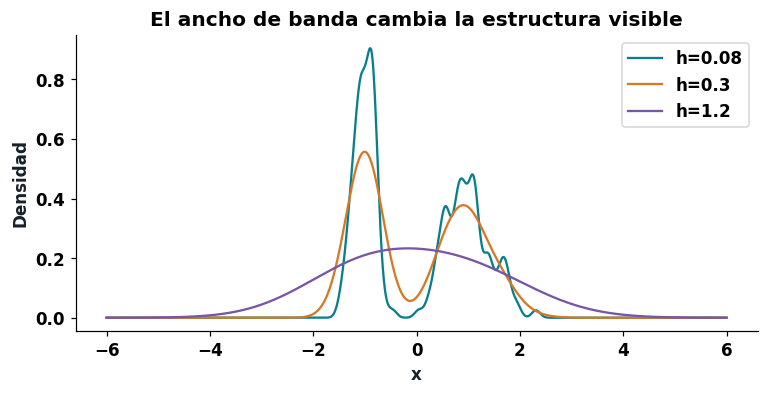

In [2]:
from sklearn.neighbors import KernelDensity
from scipy.integrate import trapezoid
rng = np.random.default_rng(42)
z = np.r_[rng.normal(-1,.25,100),rng.normal(1,.45,100)][:,None]
line = np.linspace(-6,6,3000)
fig, ax = plt.subplots(figsize=(8,3.5))
for h in [.08,.3,1.2]:
    model = KernelDensity(bandwidth=h).fit(z)
    density = np.exp(model.score_samples(line[:,None]))
    ax.plot(line,density,label=f'h={h}')
    integral = trapezoid(density,line)
    print(f'h={h}: integral aproximada={integral:.6f}')
    assert abs(integral-1)<.002
ax.set(xlabel='x',ylabel='Densidad',title='El ancho de banda cambia la estructura visible'); ax.legend()
savefig(fig,'06_bandwidth_1d')

## 2. Derivar y después elegir
En una aproximación interior:
$$\mathrm{AMISE}(h)=A h^4+\frac{B}{nh^d}.$$
Derivar respecto de $h$ da $4Ah^3-dB/(nh^{d+1})=0$ y $h\propto n^{-1/(d+4)}$.
Los términos constantes dependen del kernel y de la densidad desconocida. No es una regla universal de ancho de banda.

Usamos tres particiones temporales expansivas dentro de enero–septiembre. Cada KDE se ajusta solo con el
pasado del fold y se evalúa sobre el bloque siguiente. La puntuación es la media de log-densidades por observación.

,h,mean,std
0,0.1,-6.533944,1.612648
1,0.2,-4.327298,0.352372
2,0.4,-3.897100,0.060777
3,0.8,-3.992702,0.049093
4,1.6,-4.323260,0.047025
5,3.2,-4.940892,0.042710


Ancho congelado (km): 0.4


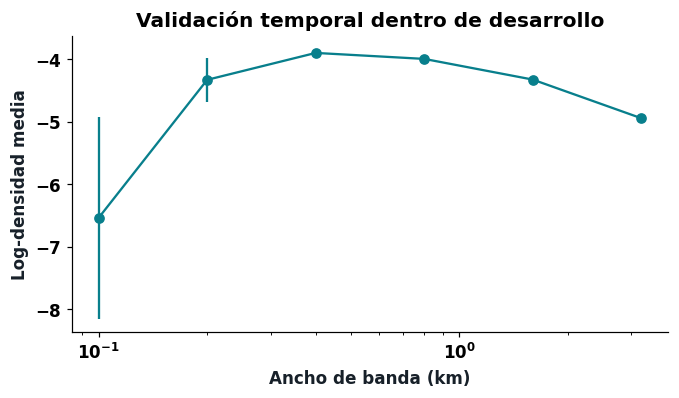

In [3]:
from sklearn.model_selection import TimeSeriesSplit
bandwidths = [.1,.2,.4,.8,1.6,3.2]
folds = list(TimeSeriesSplit(n_splits=3).split(X))
rows = []
for h in bandwidths:
    for fold,(train,validation) in enumerate(folds,1):
        assert frame.iloc[train].pickup_datetime.max() <= frame.iloc[validation].pickup_datetime.min()
        model = KernelDensity(bandwidth=h,kernel='gaussian').fit(X[train])
        rows.append(dict(h=h,fold=fold,mean_log_density=model.score_samples(X[validation]).mean(),
                         n_train=len(train),n_validation=len(validation)))
scores = pd.DataFrame(rows)
cv = scores.groupby('h').mean_log_density.agg(['mean','std']).reset_index()
display(cv)
best_h = float(cv.loc[cv['mean'].idxmax(),'h'])
kde = KernelDensity(bandwidth=best_h,kernel='gaussian').fit(X)
save_table(scores,'kde_folds'); save_table(cv,'kde_seleccion')
print('Ancho congelado (km):',best_h)
fig,ax = plt.subplots(figsize=(7,3.5))
ax.errorbar(cv.h,cv['mean'],yerr=cv['std'],fmt='o-'); ax.set_xscale('log')
ax.set(xlabel='Ancho de banda (km)',ylabel='Log-densidad media',title='Validación temporal dentro de desarrollo')
savefig(fig,'07_kde_cv')

### Para resolver

¿Por qué no comparar score(X) de modelos ajustados con distintos n sin normalizar? ¿Por qué no usar la altura del pico para elegir h?

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

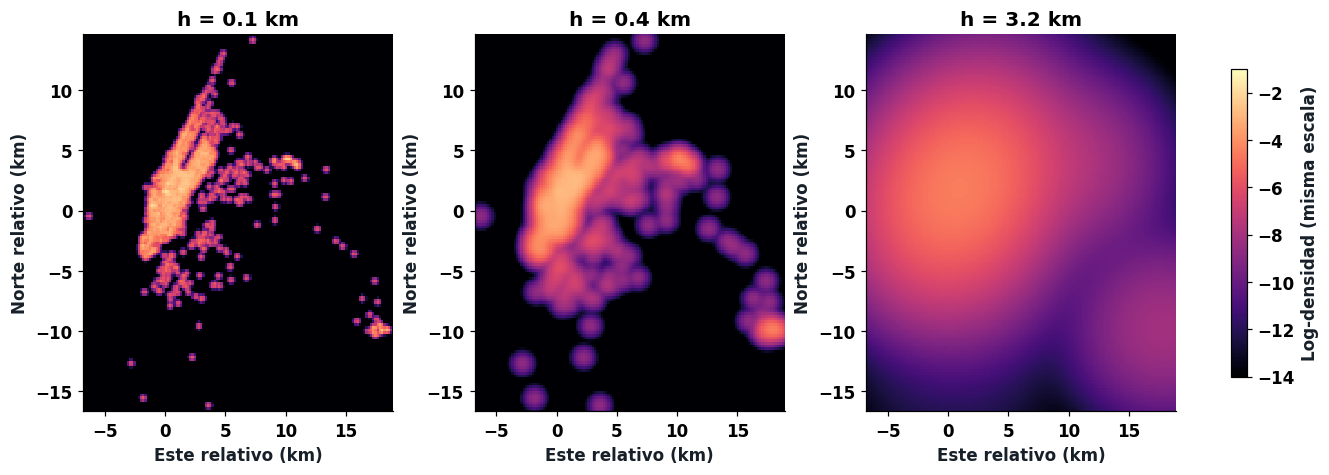

In [4]:
xx,yy,grid = density_grid(X)
fig,axes = plt.subplots(1,3,figsize=(12,4.5),layout='constrained')
for ax,h in zip(axes,[.1,best_h,3.2]):
    model=KernelDensity(bandwidth=h).fit(X)
    log_density=model.score_samples(grid).reshape(xx.shape)
    contour=ax.pcolormesh(xx,yy,log_density,shading='auto',cmap='magma',vmin=-14,vmax=-1)
    spatial_axes(ax,X,f'h = {h:g} km')
fig.colorbar(contour,ax=list(axes),label='Log-densidad (misma escala)',shrink=.65)
savefig(fig,'08_kde_espacial')

## 3. Kernel y soporte
Epanechnikov tiene soporte compacto: fuera de los discos de radio h la densidad es cero y su logaritmo es
menos infinito. Eso puede penalizarlo severamente en validación temporal. Aquí lo comparamos visualmente,
sin ocultar ceros ni escogerlo a partir del test. Ni GMM ni esta KDE conocen ríos o calles.

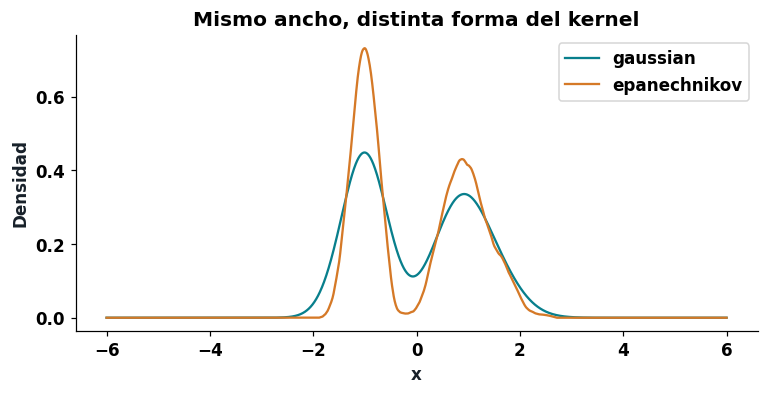

Masa KDE en [-3,3] × [-4,4] km: 0.7263539672486751
Fracción empírica: 0.735


In [5]:
fig,ax=plt.subplots(figsize=(8,3.5))
for kernel in ['gaussian','epanechnikov']:
    model=KernelDensity(bandwidth=.4,kernel=kernel).fit(z)
    ax.plot(line,np.exp(model.score_samples(line[:,None])),label=kernel)
ax.set(xlabel='x',ylabel='Densidad',title='Mismo ancho, distinta forma del kernel'); ax.legend()
savefig(fig,'09_kernels')
# Región fija de ejemplo, expresada en las mismas coordenadas relativas del modelo.
rx=np.linspace(-3,3,220); ry=np.linspace(-4,4,220)
rxx,ryy=np.meshgrid(rx,ry)
values=np.exp(kde.score_samples(np.c_[rxx.ravel(),ryy.ravel()])).reshape(rxx.shape)
mass=trapezoid(trapezoid(values,rx,axis=1),ry)
assert 0<=mass<=1.001
print('Masa KDE en [-3,3] × [-4,4] km:',mass)
print('Fracción empírica:',np.mean((abs(X[:,0])<=3)&(abs(X[:,1])<=4)))

## 4. Comparación temporal final con GMM
El cuaderno reproduce la selección BIC únicamente con desarrollo, sin depender de tablas de una ejecución
anterior. No consulta test para elegir ni requiere haber ejecutado otro cuaderno.

In [6]:
from sklearn.mixture import GaussianMixture
candidates=[]
for covariance in ['full','diag']:
    for k in range(1,9):
        m=GaussianMixture(k,covariance_type=covariance,n_init=5,max_iter=400,
                          reg_covar=1e-5,random_state=42).fit(X)
        candidates.append(dict(k=k,covariance=covariance,bic=m.bic(X),converged=m.converged_))
selection=pd.DataFrame(candidates)
row=selection[selection.converged].sort_values('bic').iloc[0]
gmm=GaussianMixture(int(row.k),covariance_type=row.covariance,n_init=5,max_iter=400,
                    reg_covar=1e-5,random_state=42).fit(X)
test=load_data('test'); Xt=test[['x_km','y_km']].to_numpy()
comparison=[]
for name,model in [('GMM',gmm),('KDE',kde)]:
    logp=model.score_samples(Xt)
    comparison.append(dict(model=name,mean_log_density=float(logp.mean()),n=len(Xt)))
    print(name,'por mes:',pd.Series(logp).groupby(test.pickup_datetime.dt.month).mean().to_dict())
comparison=pd.DataFrame(comparison)
display(comparison); save_table(comparison,'densidad_test_comparacion')

D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Documentos\Universidad Externado\Pregrado en Ciencia de Datos\Machine Learning 2\.venv-week4\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


GMM por mes: {10: -3.697354171731579, 11: -3.733753144219047, 12: -3.7436703467938517}


KDE por mes: {10: -3.7589843664170854, 11: -3.76792211150625, 12: -3.8329555324326736}


,model,mean_log_density,n
0,GMM,-3.723905,7311
1,KDE,-3.785522,7311


### Para resolver

Ticket: explique por qué densidad, masa en un área y número de vehículos necesarios son tres cantidades diferentes.

**Mi respuesta y evidencia:**

_Escriba aquí su razonamiento; incluya unidades y una limitación._

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.